In [3]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../analysisFunctions'))
sys.path.insert(0, dir1)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
from hyperion_utils import *
import doubleml as dml
import pymc as pm
import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import causalpy as cp
import pymc_bart as pmb
import arviz as az

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:94: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(


In [4]:
myDfs = readDfs()

In [5]:
print(myDfs['Description_tables_variables'][['Tables', 'Variable', 'LabelTranslated', 'Label']].to_string())

         Tables                          Variable                                                                                      LabelTranslated                                                                                                 Label
0           ADL                            SUBJID                                                                     Subject Identifier for the Study                                                                      Subject Identifier for the Study
1           ADL                             ADL_0                                                                    Has the ADL score been completed?                                                                      Le score ADL a t-il été complété
2           ADL                        ADL_1_TEMP                                                      Personal hygiene (intermediate field for entry)                                                  Hygiène corporelle (champ intermediaire p

In [6]:
bio_data_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[52:76])
bio_data_columns.append('SUBJID')
bio_data_columns_descr = list(myDfs['Description_tables_variables']['Label'].iloc[52:76])
bio_visit_column = 'VISIT'
cpc_column = 'CPC_SC3'
group_colums = ['V0_BRAS2', 'groupe']
ds_columns = 'DS_DATA_REFUS'
ecg_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[137:154])
ecg_columns_descr = list(myDfs['Description_tables_variables']['LabelTranslated'].iloc[137:154])
j0_drop_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[362:384])
j0_reflex_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[273:285])
j0_reflex_columns_descr = list(myDfs['Description_tables_variables']['LabelTranslated'].iloc[273:285])
sofa_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[586:593])
sofa_columns.append('SUBJID')
ei_columns = list(myDfs['Description_tables_variables']['Variable'].iloc[158:168])
ei_columns = ei_columns + (['SUBJID', 'EI_ARYTHMI', 'EI_ANTIEPILEPTIQ'])

In [7]:
myPredictorsDf = pd.read_csv('../predictorsDf.csv')

In [13]:
myXValue = myPredictorsDf.drop(columns= ['CPC_SC3', 'CPC12', 'J0_SEX', 'SUBJID', 'BARTHEL_SC', 'SOFA_SC7', 'DS_DC', 'DAYS_ALIVE_30', 'J0_GLASGOW_CONTROLE', 'J0_CORDA_DOS'])
myFilter = myPredictorsDf['groupe'] != 2
myXValue = myXValue[myFilter]
myNumericalColumns = myXValue.columns[myXValue.nunique() > 10]
myCategoricalColumns = myXValue.columns[(myXValue.nunique() <= 10)]
myYValue = myPredictorsDf['CPC12']

# Preprocessing step still needed
myXValue.fillna(0, inplace=True)
# Preprocessing step still needed

X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['CPC12', 'groupe']], test_size=0.20)

In [14]:
with pm.Model() as model:
  X_shared = pm.MutableData('X_shared', X_train)
  y_shared = pm.MutableData('y_shared', y_train)
  u = pmb.BART('u', X = X_shared, Y= y_train, m=20)
  p = 1 / (1 + np.exp(-u))
  y_obs= pm.Bernoulli('y_obs', p=p, observed = y_shared)
  trace = pm.sample(1000, return_inferencedata=True)
# Save trace 
az.to_netcdf(trace, 'bart_model_tracedc.nc')

C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pymc\data.py:304: FutureWarning: MutableData is deprecated. All Data variables are now mutable. Use Data instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:94: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pymc\step_methods\compound.py:72: DeprecationWarning: `PGBART.stats_dtypes` is deprecated. Please update it to specify `stats_dtypes_shapes` instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppDa

Output()

In [86]:
with model:
    pm.set_data({'X_shared': X_train, 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    # Calculate the mean predicted probability
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_train, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_train, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

Sampling: [y_obs]


Output()

ROC AUC: 0.91
Accuracy: 0.85


In [83]:
with model:
    pm.set_data({'X_shared': X_test, 'y_shared': y_test})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:94: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(
Sampling: [u, y_obs]


Output()

ROC AUC: 0.86
Accuracy: 0.80


In [84]:
myXValueModified1 = X_train.copy()
myXValueModified1['groupe'] = 1.0
myXValueModified2 = X_train.copy()
myXValueModified2['groupe'] = 0.0
with model:
    pm.set_data({'X_shared': myXValueModified1, 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs1 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

with model:
    pm.set_data({'X_shared': myXValueModified2, 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs2 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data



C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:94: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(
Sampling: [u, y_obs]


Output()

C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:84: FutureWarning: ndim_supp is deprecated. Provide signature instead.
  warnings.warn(
C:\Users\mbranda1\AppData\Roaming\Python\Python310\site-packages\pytensor\tensor\random\op.py:94: FutureWarning: ndims_params is deprecated. Provide signature instead.
  warnings.warn(
Sampling: [u, y_obs]


Output()

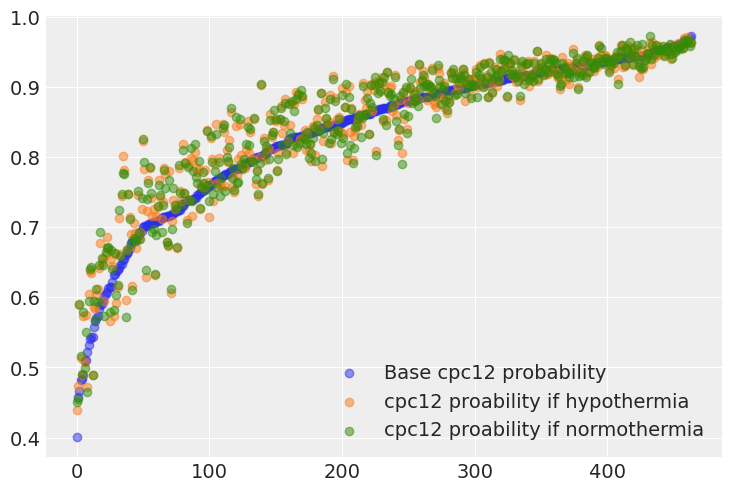

In [87]:
myYPred =  (predicted_probs1 - predicted_probs2)
myYPred = predicted_probs
myDfPreds = pd.DataFrame()
myDfPreds['base'] = predicted_probs
myDfPreds['group1'] = predicted_probs1
myDfPreds['group2'] = predicted_probs2
myDfPreds.sort_values(by=['base'], inplace=True)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['base'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group1'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group2'], alpha = 0.5)
plt.legend(['Base cpc12 probability', 'cpc12 proability if hypothermia', 'cpc12 proability if normothermia'])


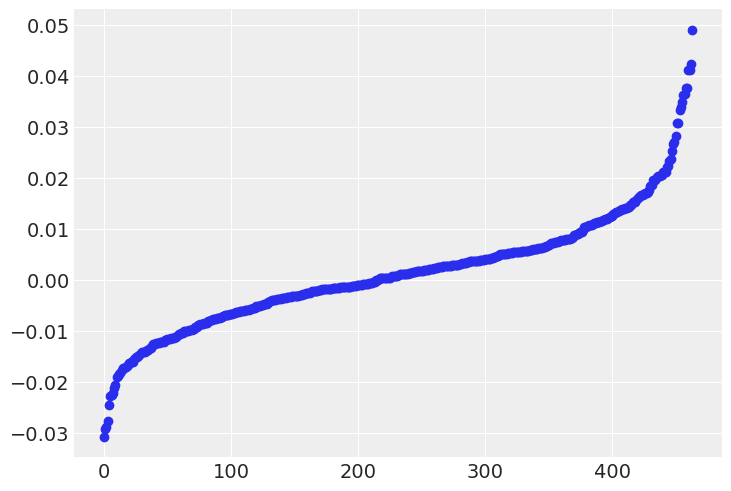

In [93]:
myDfPreds['diffs'] = (myDfPreds['group1'] - myDfPreds['group2'])
# myDfPreds['diffsscaled'] =  myDfPreds['diffs'] / myDfPreds['base']
myDfPreds.sort_values(by=['diffs'], inplace=True)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['diffs'])

In [89]:
fpr, tpr, thresholds = roc_curve(y_test, predicted_probs)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Random classifier
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [117, 464]